In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.read_csv('/kaggle/input/chat-gpt-annotating/generational_stereotypes_full_run.csv')

def run_chi2(data, col1, col2, hypothesis_name):
    contingency = pd.crosstab(data[col1], data[col2])
    chi2, p, dof, ex = chi2_contingency(contingency)
    print(f"\n--- {hypothesis_name} ---")
    print(f"Testing {col1} vs {col2}")
    print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")
    if p < 0.05:
        print("RESULT: Statistically Significant (Hypothesis Supported)")
    else:
        print("RESULT: Not Significant")
    return contingency

# H1: Noun Labels vs Negative Valence
h1_subset = df[df['label_form'].isin(['Noun', 'Adjective'])]
con_h1 = run_chi2(h1_subset, 'label_form', 'valence', "H1: Noun Labels & Negativity")

# H2: Generic/Abstract vs Oppose Stance
con_h2 = run_chi2(df, 'generic', 'stance', "H2: Genericity & Disagreement")

# H3: Hetero-Stereotype vs Valence
h3_subset = df[df['perspective'].isin(['Auto', 'Hetero'])]
con_h3 = run_chi2(h3_subset, 'perspective', 'valence', "H3: Outsider Negativity")

with open('statistical_proofs.txt', 'w') as f:
    f.write(f"H1 p-value: {chi2_contingency(pd.crosstab(h1_subset['label_form'], h1_subset['valence']))[1]}\n")
    f.write(f"H2 p-value: {chi2_contingency(pd.crosstab(df['generic'], df['stance']))[1]}\n")


--- H1: Noun Labels & Negativity ---
Testing label_form vs valence
Chi2: 11.5959, p-value: 0.0089
RESULT: Statistically Significant (Hypothesis Supported)

--- H2: Genericity & Disagreement ---
Testing generic vs stance
Chi2: 154.9740, p-value: 0.0000
RESULT: Statistically Significant (Hypothesis Supported)

--- H3: Outsider Negativity ---
Testing perspective vs valence
Chi2: 36.7006, p-value: 0.0000
RESULT: Statistically Significant (Hypothesis Supported)


✅ Heatmap saved as 'generational_blame_heatmap.png'


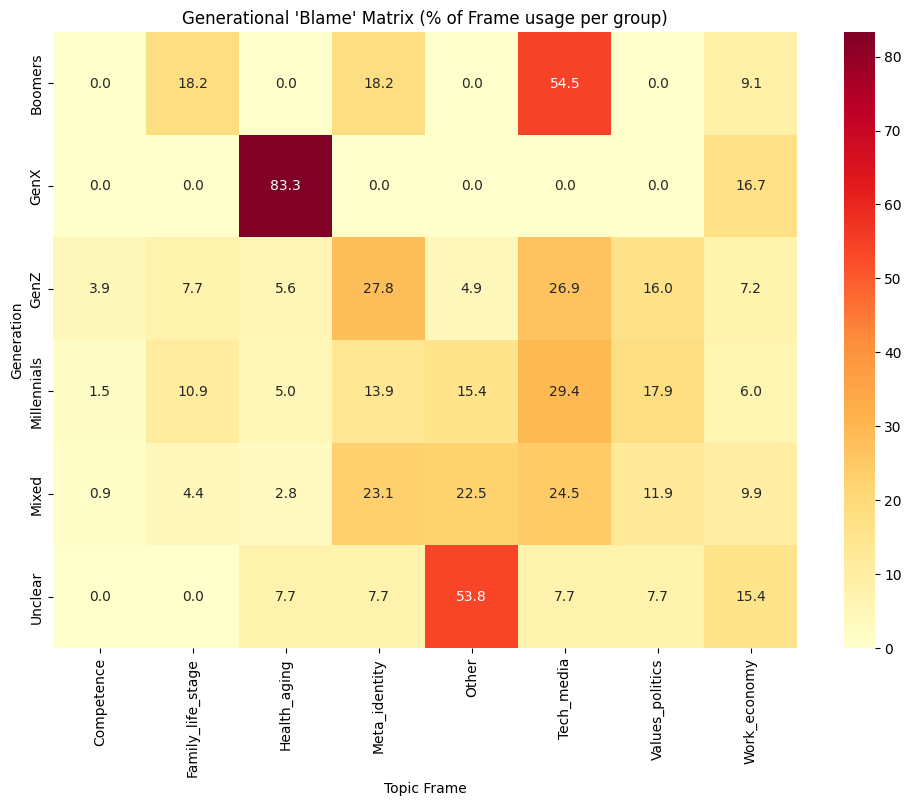

In [3]:
# Create a heatmap of Frame vs Target Group
plt.figure(figsize=(12, 8))
frame_matrix = pd.crosstab(df['target_group'], df['frame'], normalize='index') * 100
sns.heatmap(frame_matrix, annot=True, cmap="YlOrRd", fmt=".1f")
plt.title("Generational 'Blame' Matrix (% of Frame usage per group)")
plt.xlabel("Topic Frame")
plt.ylabel("Generation")
plt.savefig('generational_blame_heatmap.png')
print("✅ Heatmap saved as 'generational_blame_heatmap.png'")

In [4]:
# Extract the rare groups
deep_dive = df[df['target_group'].isin(['Boomers', 'GenX'])]
deep_dive.to_csv('rare_generations_deep_dive.csv', index=False)
print(f"✅ Extracted {len(deep_dive)} rows for Boomers/GenX into 'rare_generations_deep_dive.csv'")

# Print them for immediate review
for i, row in deep_dive.iterrows():
    print(f"\n--- TARGET: {row['target_group']} | FRAME: {row['frame']} ---")
    print(f"Text: {row['parent_text']}")
    print(f"Reasoning: {row['reasoning']}")

✅ Extracted 17 rows for Boomers/GenX into 'rare_generations_deep_dive.csv'

--- TARGET: Boomers | FRAME: Meta_identity ---
Text: All that and didn't read what I posted: "were turning 30, 30 years ago."
Reasoning: PROBLEM: Parent claims the other person misunderstood/misread the post (“didn't read what I posted”). CAUSE: Misreading the key phrase about Boomers “were turning 30, 30 years ago.” MORAL EVAL: Mild reproach/critique of the other person’s reading comprehension/attention. Reply accepts fault (“didn't read it correctly”) and explains effort, so stance is Support (concedes the parent’s correction rather than contesting it).

--- TARGET: GenX | FRAME: Health_aging ---
Text: My dad drank alcohol before he turned 14. How was that possible? Back in the 1980s, most of his high school friends usually drank alcohol and smoked cigarettes.

(My dad stopped drinking alcohol and smoking cigarettes after marrying my mom. Now he only drinks at parties.)
Reasoning: PROBLEM: Parent expresses pu

In [5]:
reframing_stats = df.groupby('perspective')['reframing'].mean()
print("\n--- Reframing Frequency by Perspective ---")
print(reframing_stats)


--- Reframing Frequency by Perspective ---
perspective
Auto       0.366071
Hetero     0.571429
Mixed      0.450980
Unclear    0.401840
Name: reframing, dtype: float64


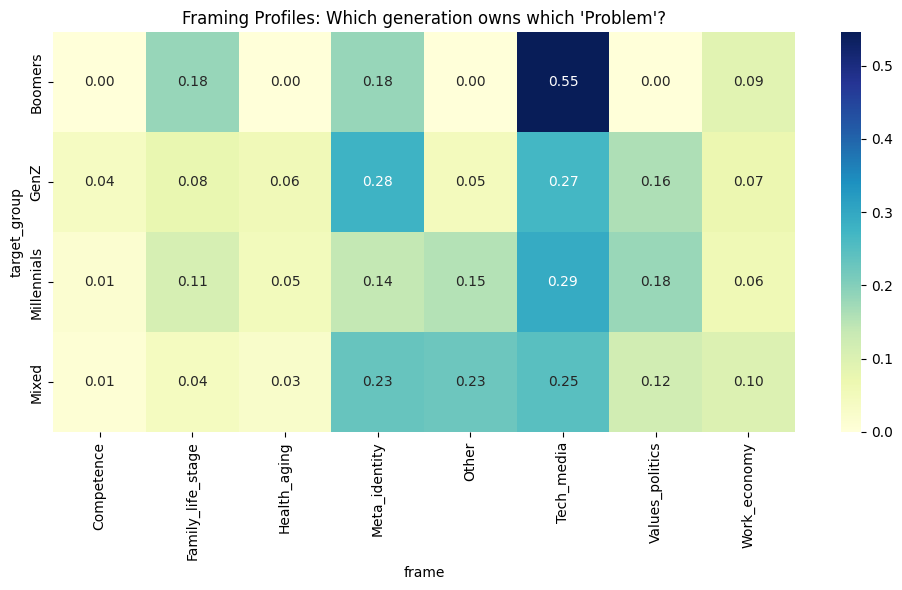

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/chat-gpt-annotating/generational_stereotypes_full_run.csv')

# Filter for the main groups
main_groups = df[df['target_group'].isin(['GenZ', 'Millennials', 'Boomers', 'Mixed'])]

plt.figure(figsize=(10, 6))

# Create a heatmap showing the percentage of each frame used per generation
ct = pd.crosstab(main_groups['target_group'], main_groups['frame'], normalize='index')
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlGnBu")

plt.title("Framing Profiles: Which generation owns which 'Problem'?")
plt.tight_layout()
plt.savefig('final_framing_heatmap.png')


--- Negativity Test ---
Proportion of Negative by subreddit_type:
subreddit_type
general     20.903226
specific    41.866330
Name: is_target, dtype: float64
p-value: 0.0000

--- Disagreement Test ---
Proportion of Oppose by subreddit_type:
subreddit_type
general     28.516129
specific    24.085750
Name: is_target, dtype: float64
p-value: 0.0000

✅ Plot saved as 'subreddit_saltiness_plot.png'


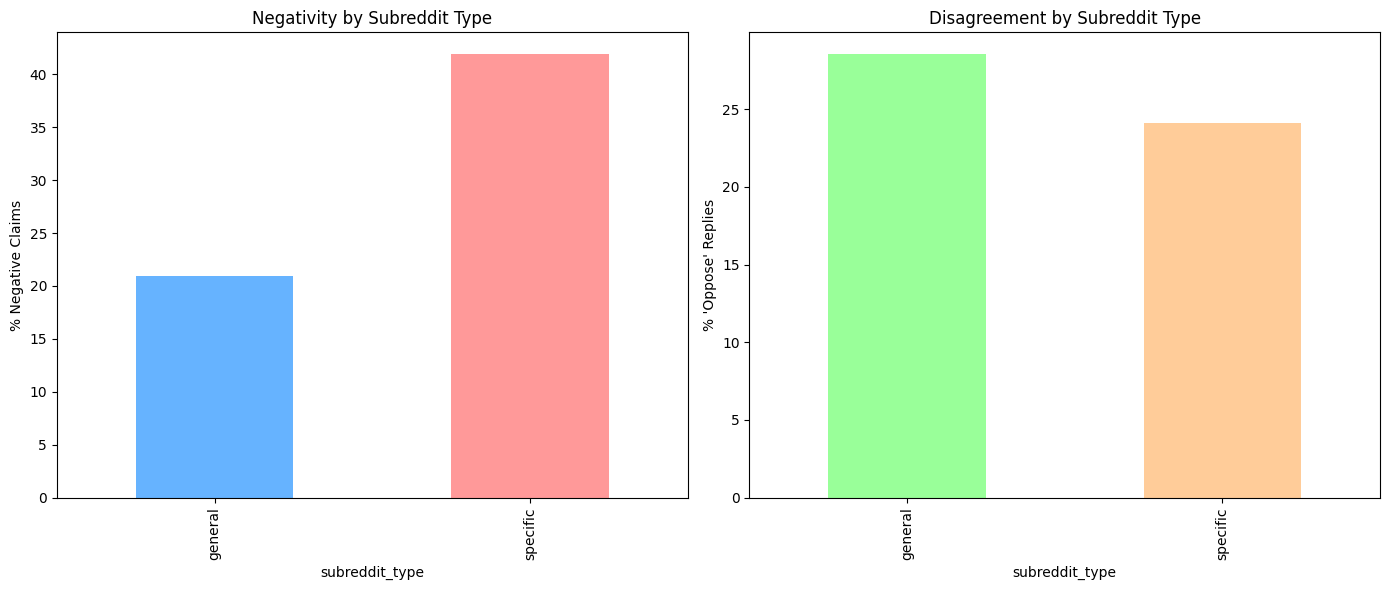

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.read_csv('/kaggle/input/chat-gpt-annotating/generational_stereotypes_full_run.csv')

# 1. Define and Run the Saltiness Tests
def run_saltiness_test(df, group_col, target_col, target_value, label):
    df['is_target'] = df[target_col] == target_value
    
    # Calculate percentages
    props = df.groupby(group_col)['is_target'].mean() * 100
    
    # Statistical Chi-Square Test
    contingency = pd.crosstab(df[group_col], df[target_col])
    chi2, p, dof, ex = chi2_contingency(contingency)
    
    print(f"\n--- {label} Test ---")
    print(f"Proportion of {target_value} by {group_col}:")
    print(props)
    print(f"p-value: {p:.4f}")
    return props

# Metric A: Negativity (Negative Valence)
neg_props = run_saltiness_test(df, 'subreddit_type', 'valence', 'Negative', 'Negativity')

# Metric B: Conflict (Oppose Stance)
oppose_props = run_saltiness_test(df, 'subreddit_type', 'stance', 'Oppose', 'Disagreement')

# 2. Visualizing the "Saltiness"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

neg_props.plot(kind='bar', ax=ax1, color=['#66b3ff', '#ff9999'])
ax1.set_title("Negativity by Subreddit Type")
ax1.set_ylabel("% Negative Claims")

oppose_props.plot(kind='bar', ax=ax2, color=['#99ff99', '#ffcc99'])
ax2.set_title("Disagreement by Subreddit Type")
ax2.set_ylabel("% 'Oppose' Replies")

plt.tight_layout()
plt.savefig('subreddit_saltiness_plot.png')
print("\n✅ Plot saved as 'subreddit_saltiness_plot.png'")